# 💻 Proyek Akhir: Analisis Harga Laptop
**Dataset:** Laptop Price Dataset (Kaggle)  
**Mata Kuliah:** Praktikum Sistem Informasi Manajemen  
**Kom A2**  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Kelompok 5**  
KHALIF AL MALIK YALES (24171226)   
MUHAMMAD RAMADHAN (24171234)  
M.FIKRI RAMADHAN SEMBIRING (241712027)


---
## 📋 Alur Proyek

| Tahap | Nama | Output |
|---|---|---|
| 0 | **Data Gathering** | Dataset siap pakai |
| 1 | **Library & Setup** | Environment siap |
| 2 | **Assessing Data** | Laporan kualitas data |
| 3 | **Data Wrangling** | Dataset bersih |
| 4 | **EDA** | Temuan & pola |
| 5 | **Visualisasi** | 6 grafik + narasi |
| 6 | **Analisis Masalah** | Temuan + rekomendasi |
| 7 | **SPK** | Ranking SAW & TOPSIS |

---
## 🌐 Tahap 0: Data Gathering

### Sumber Dataset
- **Platform:** Kaggle  
- **URL:** https://www.kaggle.com/datasets/ionaskel/laptop-prices  
- **Nama file:** `laptop_price.csv`  
- **Lisensi:** CC0 (Public Domain)

### Cara Mengunduh (2 Opsi)

**Opsi A — Manual:**  
1. Buka link Kaggle di atas  
2. Klik tombol *Download*  
3. Upload file ke Google Colab via panel *Files* (ikon folder di kiri)

**Opsi B — Kaggle API (otomatis di Colab):**  
Jalankan cell di bawah ini (butuh file `kaggle.json` dari akun Kaggle kamu)

### Deskripsi Dataset

| Atribut | Keterangan |
|---|---|
| **Jumlah baris** | 1.303 laptop |
| **Jumlah kolom** | 13 kolom |
| **Periode data** | ~2017–2018 |
| **Topik** | Spesifikasi & harga laptop dari berbagai brand |

### Relevansi Dataset
Dataset ini cocok untuk SPK karena memiliki banyak atribut teknis yang dapat dijadikan kriteria pengambilan keputusan (harga, RAM, storage, GPU, dll).

In [3]:
# ── Opsi B: Download via Kaggle API ─────────────────────────
# Jalankan cell ini hanya jika menggunakan Kaggle API
# Lewati jika sudah upload manual

# from google.colab import files
# files.upload()  # upload kaggle.json

# import os
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 600)

# !kaggle datasets download -d ionaskel/laptop-prices --unzip

print("ℹ️  Jika sudah upload manual, langsung lanjut ke Tahap 1.")
print("ℹ️  Pastikan file bernama 'laptop_price.csv' di direktori yang sama.")

ℹ️  Jika sudah upload manual, langsung lanjut ke Tahap 1.
ℹ️  Pastikan file bernama 'laptop_price.csv' di direktori yang sama.


In [4]:
# ── Upload Dataset dari Komputer ke Google Colab ─────────────
# Jalankan cell ini, klik tombol "Choose Files", lalu pilih file laptop_price.csv

from google.colab import files
import io

print("📂 Silakan pilih file laptop_price.csv dari komputer kamu...")
uploaded = files.upload()

# Verifikasi file berhasil diupload
if 'laptop_price.csv' in uploaded:
    print("✅ File 'laptop_price.csv' berhasil diupload!")
    print(f"   Ukuran: {len(uploaded['laptop_price.csv']):,} bytes")
else:
    nama_file = list(uploaded.keys())[0]
    print(f"⚠️  File diupload dengan nama '{nama_file}'")
    print(f"   Mengganti nama menjadi 'laptop_price.csv'...")
    import os
    os.rename(nama_file, 'laptop_price.csv')
    print("✅ Selesai. Lanjutkan ke cell berikutnya.")

📂 Silakan pilih file laptop_price.csv dari komputer kamu...


Saving laptop_price.csv to laptop_price.csv
✅ File 'laptop_price.csv' berhasil diupload!
   Ukuran: 198,100 bytes


---
## 📦 Tahap 1: Library & Setup

### Library yang Digunakan

| Library | Fungsi |
|---|---|
| `pandas` | Manipulasi dan analisis data tabular |
| `numpy` | Komputasi numerik, matriks, dan array |
| `matplotlib` | Visualisasi grafik dasar |
| `seaborn` | Visualisasi statistik berbasis matplotlib |
| `math` | Fungsi matematika standar Python |
| `warnings` | Menekan pesan warning yang tidak relevan |
| `re` | Regular expression untuk ekstrak teks |

> ⚠️ Semua library di atas sudah tersedia secara default di Google Colab.  
> **Tidak ada library SPK eksternal** — SAW & TOPSIS diimplementasi manual dengan NumPy.

In [5]:
# ── Install jika diperlukan (biasanya sudah ada di Colab) ────
# !pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import math
import re
import warnings
warnings.filterwarnings('ignore')

# ── Verifikasi versi library ──────────────────────────────────
print("=== VERSI LIBRARY ===")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  matplotlib : {plt.matplotlib.__version__}")
print(f"  seaborn    : {sns.__version__}")

# ── Konfigurasi tampilan global ───────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 120)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'figure.titlesize' : 13
})
sns.set_theme(style='whitegrid', palette='muted')

print()
print("✅ Semua library berhasil diimport dan dikonfigurasi.")

=== VERSI LIBRARY ===
  pandas     : 2.2.2
  numpy      : 2.0.2
  matplotlib : 3.10.0
  seaborn    : 0.13.2

✅ Semua library berhasil diimport dan dikonfigurasi.


---
## 🔎 Tahap 2: Assessing Data
Menilai kualitas data mentah sebelum dilakukan pembersihan.  
Tujuan: mengidentifikasi **missing values**, **duplikat**, **tipe data salah**, **outlier**, dan **inkonsistensi nilai**.

In [6]:
# ── 2.1 Load Dataset Mentah ──────────────────────────────────
df_raw = pd.read_csv('laptop_price.csv', encoding='latin-1')

print(f"{'='*50}")
print(f"  INFORMASI UMUM DATASET")
print(f"{'='*50}")
print(f"  Jumlah baris  : {df_raw.shape[0]:,}")
print(f"  Jumlah kolom  : {df_raw.shape[1]}")
print(f"  Total sel     : {df_raw.shape[0] * df_raw.shape[1]:,}")
print()
df_raw.head(10)

  INFORMASI UMUM DATASET
  Jumlah baris  : 1,303
  Jumlah kolom  : 13
  Total sel     : 16,939



,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
5,6,Acer,Aspire 3,Notebook,15.60,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00
6,7,Apple,MacBook Pro,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97
7,8,Apple,Macbook Air,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,1158.70
8,9,Asus,ZenBook UX430UN,Ultrabook,14.00,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,1495.00
9,10,Acer,Swift 3,Ultrabook,14.00,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,770.00


In [7]:
# ── 2.2 Struktur & Tipe Data ─────────────────────────────────
print("=== INFO TIPE DATA ===")
df_raw.info()

=== INFO TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [8]:
# ── 2.3 Pemeriksaan Missing Values ───────────────────────────
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah_Null']
missing['Persentase (%)'] = (missing['Jumlah_Null'] / len(df_raw) * 100).round(2)
missing['Status'] = missing['Jumlah_Null'].apply(lambda x: '✅ Bersih' if x == 0 else '⚠️ Ada Null')
print(missing.to_string(index=False))
print()
print(f"Total kolom dengan missing value: {(missing['Jumlah_Null'] > 0).sum()}")

=== MISSING VALUES ===
           Kolom  Jumlah_Null  Persentase (%)   Status
       laptop_ID            0            0.00 ✅ Bersih
         Company            0            0.00 ✅ Bersih
         Product            0            0.00 ✅ Bersih
        TypeName            0            0.00 ✅ Bersih
          Inches            0            0.00 ✅ Bersih
ScreenResolution            0            0.00 ✅ Bersih
             Cpu            0            0.00 ✅ Bersih
             Ram            0            0.00 ✅ Bersih
          Memory            0            0.00 ✅ Bersih
             Gpu            0            0.00 ✅ Bersih
           OpSys            0            0.00 ✅ Bersih
          Weight            0            0.00 ✅ Bersih
     Price_euros            0            0.00 ✅ Bersih

Total kolom dengan missing value: 0


In [9]:
# ── 2.4 Pemeriksaan Duplikat ─────────────────────────────────
jumlah_duplikat = df_raw.duplicated().sum()
print(f"=== DUPLIKAT ===")
print(f"Jumlah baris duplikat : {jumlah_duplikat}")
print(f"Status                : {'⚠️ Ada duplikat' if jumlah_duplikat > 0 else '✅ Tidak ada duplikat'}")

if jumlah_duplikat > 0:
    print()
    print("Baris duplikat:")
    print(df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(10))

=== DUPLIKAT ===
Jumlah baris duplikat : 0
Status                : ✅ Tidak ada duplikat


In [10]:
# ── 2.5 Pemeriksaan Outlier (Harga & Inches) ─────────────────
print("=== DETEKSI OUTLIER (Metode IQR) ===")
print()

def deteksi_outlier_iqr(series, nama_kolom):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outlier     = series[(series < batas_bawah) | (series > batas_atas)]
    print(f"  [{nama_kolom}]")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Batas bawah : {batas_bawah:.2f}")
    print(f"    Batas atas  : {batas_atas:.2f}")
    print(f"    Jumlah outlier: {len(outlier)} baris ({len(outlier)/len(series)*100:.1f}%)")
    print()

deteksi_outlier_iqr(df_raw['Price_euros'], 'Price_euros')
deteksi_outlier_iqr(df_raw['Inches'], 'Inches')

=== DETEKSI OUTLIER (Metode IQR) ===

  [Price_euros]
    Q1=599.00, Q3=1487.88, IQR=888.88
    Batas bawah : -734.32
    Batas atas  : 2821.20
    Jumlah outlier: 29 baris (2.2%)

  [Inches]
    Q1=14.00, Q3=15.60, IQR=1.60
    Batas bawah : 11.60
    Batas atas  : 18.00
    Jumlah outlier: 39 baris (3.0%)



In [11]:
# ── 2.6 Pemeriksaan Inkonsistensi Nilai Kategorik ─────────────
print("=== INKONSISTENSI NILAI KATEGORIK ===")
print()

kolom_kategorik = ['Company', 'TypeName', 'Ram', 'OpSys', 'Weight']
for kolom in kolom_kategorik:
    unique_vals = sorted(df_raw[kolom].unique())
    print(f"  [{kolom}] — {len(unique_vals)} nilai unik:")
    print(f"  {unique_vals}")
    print()

=== INKONSISTENSI NILAI KATEGORIK ===

  [Company] — 19 nilai unik:
  ['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']

  [TypeName] — 6 nilai unik:
  ['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']

  [Ram] — 9 nilai unik:
  ['12GB', '16GB', '24GB', '2GB', '32GB', '4GB', '64GB', '6GB', '8GB']

  [OpSys] — 9 nilai unik:
  ['Android', 'Chrome OS', 'Linux', 'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS']

  [Weight] — 179 nilai unik:
  ['0.69kg', '0.81kg', '0.91kg', '0.920kg', '0.92kg', '0.97kg', '0.98kg', '0.99kg', '1.05kg', '1.08kg', '1.09kg', '1.10kg', '1.11kg', '1.12kg', '1.13kg', '1.14kg', '1.15kg', '1.16kg', '1.17kg', '1.18kg', '1.19kg', '1.1kg', '1.21kg', '1.22kg', '1.23kg', '1.24kg', '1.252kg', '1.25kg', '1.26kg', '1.27kg', '1.28kg', '1.29kg', '1.2kg', '1.31kg', '1.32kg', '1.34kg', '1.35kg', '1

In [12]:
# ── 2.7 Pemeriksaan Tipe Data Salah ──────────────────────────
print("=== KOLOM YANG PERLU KONVERSI TIPE DATA ===")
print()
masalah_tipe = pd.DataFrame({
    'Kolom'          : ['Ram', 'Weight', 'Price_euros'],
    'Tipe Saat Ini'  : ['object', 'object', 'float64'],
    'Seharusnya'     : ['int64', 'float64', 'float64 (IDR)'],
    'Contoh Nilai'   : [
        df_raw['Ram'].iloc[0],
        df_raw['Weight'].iloc[0],
        df_raw['Price_euros'].iloc[0]
    ],
    'Masalah'        : [
        'Ada suffix "GB"',
        'Ada suffix "kg"',
        'Perlu konversi ke IDR'
    ]
})
print(masalah_tipe.to_string(index=False))

print()
print("=== RINGKASAN TEMUAN ASSESSING ===")
print("  1. Missing values  : Tidak ada ✅")
print("  2. Duplikat        : Tidak ada ✅")
print("  3. Outlier harga   : Ada (laptop premium, wajar) ⚠️")
print("  4. Tipe data salah : Ram, Weight perlu konversi ⚠️")
print("  5. Inkonsistensi   : OpSys 'No OS' vs 'Windows 10' perlu standarisasi ⚠️")
print()
print("→ Lanjut ke Tahap 3: Data Wrangling untuk memperbaiki temuan di atas.")

=== KOLOM YANG PERLU KONVERSI TIPE DATA ===

      Kolom Tipe Saat Ini    Seharusnya Contoh Nilai               Masalah
        Ram        object         int64          8GB       Ada suffix "GB"
     Weight        object       float64       1.37kg       Ada suffix "kg"
Price_euros       float64 float64 (IDR)      1339.69 Perlu konversi ke IDR

=== RINGKASAN TEMUAN ASSESSING ===
  1. Missing values  : Tidak ada ✅
  2. Duplikat        : Tidak ada ✅
  3. Outlier harga   : Ada (laptop premium, wajar) ⚠️
  4. Tipe data salah : Ram, Weight perlu konversi ⚠️
  5. Inkonsistensi   : OpSys 'No OS' vs 'Windows 10' perlu standarisasi ⚠️

→ Lanjut ke Tahap 3: Data Wrangling untuk memperbaiki temuan di atas.


---
## 🧹 Tahap 3: Data Wrangling
Membersihkan dan mentransformasi data berdasarkan temuan dari Assessing Data.

In [13]:
# ── 3.1 Salin Dataset & Hapus Kolom ID ───────────────────────
df = df_raw.copy()
df.drop(columns=['laptop_ID'], inplace=True)
print(f"✅ Kolom 'laptop_ID' dihapus. Shape: {df.shape}")

✅ Kolom 'laptop_ID' dihapus. Shape: (1303, 12)


In [14]:
# ── 3.2 Konversi Tipe Data ────────────────────────────────────
# Ram: "8GB" → 8
df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

# Weight: "1.37kg" → 1.37
df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

# Harga: EUR → IDR (kurs 1 EUR ≈ 17.500 IDR)
KURS_EUR_TO_IDR = 17_500
df['Price_IDR'] = (df['Price_euros'] * KURS_EUR_TO_IDR).round(0).astype(int)

print("✅ Konversi tipe data selesai.")
print(f"   Ram_GB   : {df['Ram_GB'].dtype} — contoh: {df['Ram_GB'].iloc[0]}")
print(f"   Weight_kg: {df['Weight_kg'].dtype} — contoh: {df['Weight_kg'].iloc[0]}")
print(f"   Price_IDR: {df['Price_IDR'].dtype} — contoh: Rp {df['Price_IDR'].iloc[0]:,}")

✅ Konversi tipe data selesai.
   Ram_GB   : int64 — contoh: 8
   Weight_kg: float64 — contoh: 1.37
   Price_IDR: int64 — contoh: Rp 23,444,575


In [15]:
# ── 3.3 Feature Engineering ───────────────────────────────────

# Resolusi layar → total pixel
def ekstrak_resolusi(text):
    match = re.search(r'(\d{3,4})x(\d{3,4})', str(text))
    return int(match.group(1)) * int(match.group(2)) if match else np.nan

df['Resolusi_pixel'] = df['ScreenResolution'].apply(ekstrak_resolusi)

# Merek CPU
def ekstrak_cpu_brand(cpu_str):
    cpu_str = str(cpu_str).lower()
    if 'core i7' in cpu_str: return 'Intel Core i7'
    if 'core i5' in cpu_str: return 'Intel Core i5'
    if 'core i3' in cpu_str: return 'Intel Core i3'
    if 'celeron' in cpu_str: return 'Intel Celeron'
    if 'pentium' in cpu_str: return 'Intel Pentium'
    if 'xeon'    in cpu_str: return 'Intel Xeon'
    if 'intel'   in cpu_str: return 'Intel Lainnya'
    if 'amd'     in cpu_str: return 'AMD'
    return 'Lainnya'

df['CPU_Brand'] = df['Cpu'].apply(ekstrak_cpu_brand)

# Merek GPU
def ekstrak_gpu_brand(gpu_str):
    gpu_str = str(gpu_str).lower()
    if 'nvidia' in gpu_str:            return 'Nvidia'
    if 'amd' in gpu_str or 'radeon' in gpu_str: return 'AMD'
    if 'intel' in gpu_str:             return 'Intel'
    return 'Lainnya'

df['GPU_Brand'] = df['Gpu'].apply(ekstrak_gpu_brand)

# Tipe storage
def klasifikasi_storage(mem):
    mem = str(mem).lower()
    if 'ssd' in mem and 'hdd' in mem: return 'SSD+HDD'
    if 'ssd' in mem or 'flash' in mem: return 'SSD'
    if 'hdd' in mem:                  return 'HDD'
    return 'Lainnya'

df['Storage_Type'] = df['Memory'].apply(klasifikasi_storage)

# Kapasitas storage utama (GB)
def ekstrak_kapasitas_gb(mem):
    match_tb = re.search(r'(\d+)TB', str(mem))
    if match_tb: return int(match_tb.group(1)) * 1024
    match_gb = re.search(r'(\d+)GB', str(mem))
    if match_gb: return int(match_gb.group(1))
    return np.nan

df['Storage_GB'] = df['Memory'].apply(ekstrak_kapasitas_gb)

# Kategori harga
bins  = [0, 7_000_000, 14_000_000, 21_000_000, float('inf')]
label = ['Budget (<7 Jt)', 'Mid-Range (7-14 Jt)', 'High-End (14-21 Jt)', 'Premium (>21 Jt)']
df['Kategori_Harga'] = pd.cut(df['Price_IDR'], bins=bins, labels=label)

# Kolom harga dalam Juta untuk visualisasi
df['Price_Juta'] = df['Price_IDR'] / 1_000_000

print("✅ Feature engineering selesai.")
kolom_baru = ['Ram_GB', 'Weight_kg', 'Price_IDR', 'Resolusi_pixel',
              'CPU_Brand', 'GPU_Brand', 'Storage_Type', 'Storage_GB', 'Kategori_Harga']
print(f"   Kolom baru ditambahkan: {kolom_baru}")

✅ Feature engineering selesai.
   Kolom baru ditambahkan: ['Ram_GB', 'Weight_kg', 'Price_IDR', 'Resolusi_pixel', 'CPU_Brand', 'GPU_Brand', 'Storage_Type', 'Storage_GB', 'Kategori_Harga']


In [16]:
# ── 3.4 Verifikasi Dataset Bersih ────────────────────────────
print("=== VERIFIKASI DATASET BERSIH ===")
print(f"  Shape          : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Missing values : {df.isnull().sum().sum()}")
print()
print("=== STATISTIK DESKRIPTIF ===")
kolom_numerik = ['Ram_GB', 'Weight_kg', 'Inches', 'Price_IDR', 'Storage_GB', 'Resolusi_pixel']
df[kolom_numerik].describe().round(2)

=== VERIFIKASI DATASET BERSIH ===
  Shape          : 1,303 baris × 22 kolom
  Missing values : 0

=== STATISTIK DESKRIPTIF ===


,Ram_GB,Weight_kg,Inches,Price_IDR,Storage_GB,Resolusi_pixel
count,1303.00,1303.00,1303.00,1303.00,1303.00,1303.00
mean,8.38,2.04,15.02,19664522.35,573.50,2168806.66
std,5.08,0.67,1.43,12232658.24,428.13,1391292.40
min,2.00,0.69,10.10,3045000.00,0.00,1049088.00
25%,4.00,1.50,14.00,10482500.00,256.00,1440000.00
50%,8.00,2.04,15.60,17097500.00,500.00,2073600.00
75%,8.00,2.30,15.60,26037900.00,1024.00,2073600.00
max,64.00,4.70,18.40,106732500.00,2048.00,8294400.00


---
## 🔍 Tahap 4: Exploratory Data Analysis (EDA)
Mengeksplorasi pola, distribusi, dan hubungan antar variabel dalam dataset bersih.

In [17]:
# ── 4.1 Distribusi Harga ─────────────────────────────────────
print("=== DISTRIBUSI HARGA (IDR) ===")
stats = df['Price_IDR'].describe()
print(stats.apply(lambda x: f"Rp {x:,.0f}"))
print(f"\nSkewness : {df['Price_IDR'].skew():.3f}  (positif = ekor kanan)")
print(f"Kurtosis : {df['Price_IDR'].kurt():.3f}")

=== DISTRIBUSI HARGA (IDR) ===
count          Rp 1,303
mean      Rp 19,664,522
std       Rp 12,232,658
min        Rp 3,045,000
25%       Rp 10,482,500
50%       Rp 17,097,500
75%       Rp 26,037,900
max      Rp 106,732,500
Name: Price_IDR, dtype: object

Skewness : 1.521  (positif = ekor kanan)
Kurtosis : 4.371


In [18]:
# ── 4.2 Distribusi Variabel Kategorik ────────────────────────
print("=== DISTRIBUSI KATEGORI HARGA ===")
print(df['Kategori_Harga'].value_counts().to_string())
print()
print("=== TOP 5 BRAND ===")
print(df['Company'].value_counts().head().to_string())
print()
print("=== TIPE LAPTOP ===")
print(df['TypeName'].value_counts().to_string())
print()
print("=== DISTRIBUSI RAM ===")
print(df['Ram_GB'].value_counts().sort_index().to_string())

=== DISTRIBUSI KATEGORI HARGA ===
Kategori_Harga
Premium (>21 Jt)       463
Mid-Range (7-14 Jt)    366
High-End (14-21 Jt)    329
Budget (<7 Jt)         145

=== TOP 5 BRAND ===
Company
Dell      297
Lenovo    297
HP        274
Asus      158
Acer      103

=== TIPE LAPTOP ===
TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25

=== DISTRIBUSI RAM ===
Ram_GB
2      22
4     375
6      41
8     619
12     25
16    200
24      3
32     17
64      1


In [19]:
# ── 4.3 Matriks Korelasi ─────────────────────────────────────
print("=== KORELASI DENGAN HARGA ===")
kolom_korr = ['Price_IDR', 'Ram_GB', 'Weight_kg', 'Inches', 'Resolusi_pixel', 'Storage_GB']
korr = df[kolom_korr].corr()['Price_IDR'].sort_values(ascending=False)
for k, v in korr.items():
    bar = '█' * int(abs(v) * 20)
    print(f"  {k:<20} {v:+.4f}  {bar}")

=== KORELASI DENGAN HARGA ===
  Price_IDR            +1.0000  ████████████████████
  Ram_GB               +0.7430  ██████████████
  Resolusi_pixel       +0.5155  ██████████
  Weight_kg            +0.2104  ████
  Storage_GB           +0.0880  █
  Inches               +0.0682  █


In [20]:
# ── 4.4 Rata-rata Harga per Brand ────────────────────────────
print("=== RATA-RATA HARGA PER BRAND ===")
harga_brand = (
    df.groupby('Company')['Price_IDR']
    .agg(Rata_rata='mean', Median='median', Jumlah='count')
    .sort_values('Rata_rata', ascending=False)
)
harga_brand['Rata_rata'] = harga_brand['Rata_rata'].apply(lambda x: f"Rp {x:,.0f}")
harga_brand['Median']    = harga_brand['Median'].apply(lambda x: f"Rp {x:,.0f}")
print(harga_brand.to_string())

=== RATA-RATA HARGA PER BRAND ===
               Rata_rata         Median  Jumlah
Company                                        
Razer      Rp 58,557,500  Rp 50,732,500       7
LG         Rp 36,732,500  Rp 36,732,500       3
MSI        Rp 30,255,893  Rp 27,982,500      54
Google     Rp 29,359,167  Rp 27,282,500       3
Microsoft  Rp 28,215,396  Rp 27,466,250       6
Apple      Rp 27,373,475  Rp 23,444,575      21
Huawei     Rp 24,920,000  Rp 24,920,000       2
Samsung    Rp 24,735,278  Rp 28,857,500       9
Toshiba    Rp 22,186,719  Rp 21,201,250      48
Dell       Rp 20,756,207  Rp 17,237,500     297
Xiaomi     Rp 19,835,594  Rp 19,240,375       4
Asus       Rp 19,322,964  Rp 17,718,750     158
Lenovo     Rp 19,011,728  Rp 15,732,500     297
HP         Rp 18,686,060  Rp 16,913,750     274
Fujitsu    Rp 12,757,500  Rp 12,932,500       3
Acer       Rp 10,968,577   Rp 9,782,500     103
Chuwi       Rp 5,500,192   Rp 4,355,750       3
Mediacom    Rp 5,162,500   Rp 4,637,500       7
Vero  

In [21]:
# ── 4.5 Insight Utama ────────────────────────────────────────
print("=" * 55)
print("  INSIGHT UTAMA EDA")
print("=" * 55)
print(f"  Brand terbanyak   : {df['Company'].value_counts().index[0]} ({df['Company'].value_counts().iloc[0]} unit)")
print(f"  Tipe dominan      : {df['TypeName'].value_counts().index[0]}")
print(f"  RAM paling umum   : {df['Ram_GB'].mode()[0]} GB")
print(f"  Harga termurah    : Rp {df['Price_IDR'].min():,}")
print(f"  Harga termahal    : Rp {df['Price_IDR'].max():,}")
print(f"  Median harga      : Rp {df['Price_IDR'].median():,.0f}")
print(f"  CPU dominan       : {df['CPU_Brand'].value_counts().index[0]}")
print(f"  GPU dominan       : {df['GPU_Brand'].value_counts().index[0]}")
print(f"  Storage dominan   : {df['Storage_Type'].value_counts().index[0]}")
print(f"  Korelasi RAM→Harga: {df['Ram_GB'].corr(df['Price_IDR']):.3f}")

  INSIGHT UTAMA EDA
  Brand terbanyak   : Dell (297 unit)
  Tipe dominan      : Notebook
  RAM paling umum   : 8 GB
  Harga termurah    : Rp 3,045,000
  Harga termahal    : Rp 106,732,500
  Median harga      : Rp 17,097,500
  CPU dominan       : Intel Core i7
  GPU dominan       : Intel
  Storage dominan   : SSD
  Korelasi RAM→Harga: 0.743


---
## 📊 Tahap 5: Visualisasi Data
6 grafik berbeda untuk mengkomunikasikan temuan secara visual.

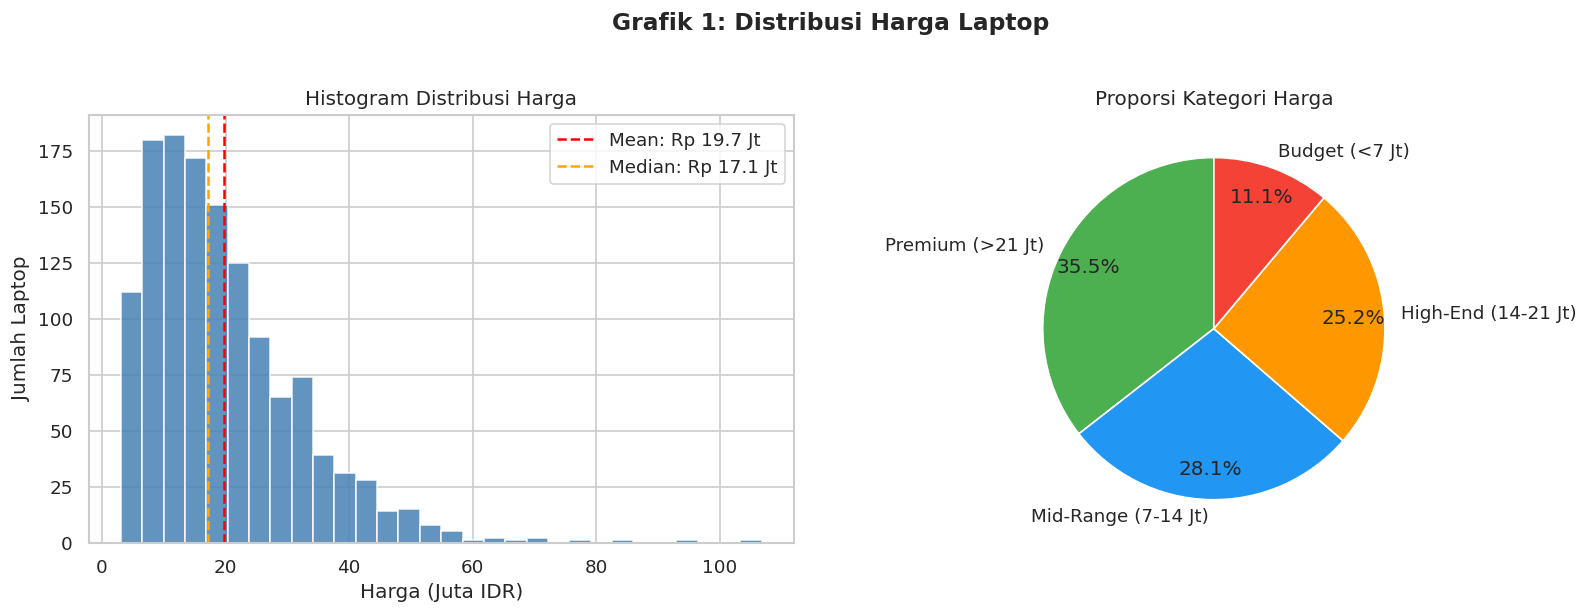

📊 Narasi: Harga laptop terdistribusi right-skewed. Sebagian besar laptop
   berada di kisaran mid-range (7–14 juta). Laptop premium (<10%) jauh
   lebih mahal dan menarik rata-rata ke atas dibanding median.


In [22]:
# ── Grafik 1: Distribusi Harga ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grafik 1: Distribusi Harga Laptop', fontsize=14, fontweight='bold', y=1.02)

axes[0].hist(df['Price_Juta'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Price_Juta'].mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f"Mean: Rp {df['Price_Juta'].mean():.1f} Jt")
axes[0].axvline(df['Price_Juta'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median: Rp {df['Price_Juta'].median():.1f} Jt")
axes[0].set_xlabel('Harga (Juta IDR)')
axes[0].set_ylabel('Jumlah Laptop')
axes[0].set_title('Histogram Distribusi Harga')
axes[0].legend()

kat_count = df['Kategori_Harga'].value_counts()
colors    = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
axes[1].pie(kat_count, labels=kat_count.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.82)
axes[1].set_title('Proporsi Kategori Harga')

plt.tight_layout()
plt.savefig('grafik1_distribusi_harga.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: Harga laptop terdistribusi right-skewed. Sebagian besar laptop")
print("   berada di kisaran mid-range (7–14 juta). Laptop premium (<10%) jauh")
print("   lebih mahal dan menarik rata-rata ke atas dibanding median.")

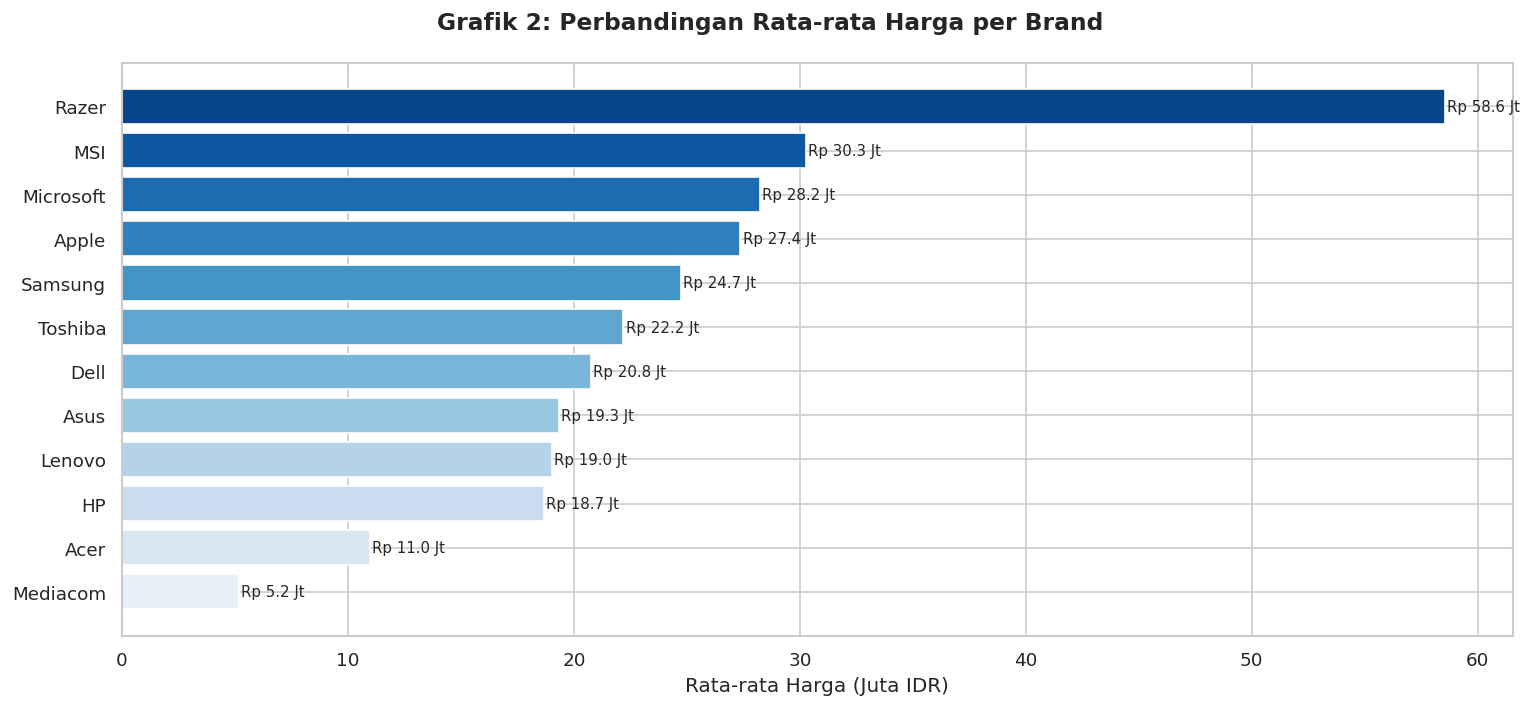

📊 Narasi: Razer dan Apple mendominasi segmen premium, sedangkan Chuwi
   dan Mediacom adalah pilihan paling terjangkau. Lenovo, meski terbanyak
   produknya, berada di kisaran mid-range.


In [23]:
# ── Grafik 2: Rata-rata Harga per Brand ──────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Grafik 2: Perbandingan Rata-rata Harga per Brand', fontsize=14, fontweight='bold')

top_brands = df['Company'].value_counts().nlargest(12).index
df_top     = df[df['Company'].isin(top_brands)]
rata_brand = (df_top.groupby('Company')['Price_Juta']
              .mean().sort_values(ascending=False).reset_index())

bars = ax.barh(rata_brand['Company'], rata_brand['Price_Juta'],
               color=sns.color_palette('Blues_r', len(rata_brand)))
for bar, val in zip(bars, rata_brand['Price_Juta']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'Rp {val:.1f} Jt', va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Rata-rata Harga (Juta IDR)')
ax.set_xlim(0, rata_brand['Price_Juta'].max() + 3)

plt.tight_layout()
plt.savefig('grafik2_harga_per_brand.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: Razer dan Apple mendominasi segmen premium, sedangkan Chuwi")
print("   dan Mediacom adalah pilihan paling terjangkau. Lenovo, meski terbanyak")
print("   produknya, berada di kisaran mid-range.")

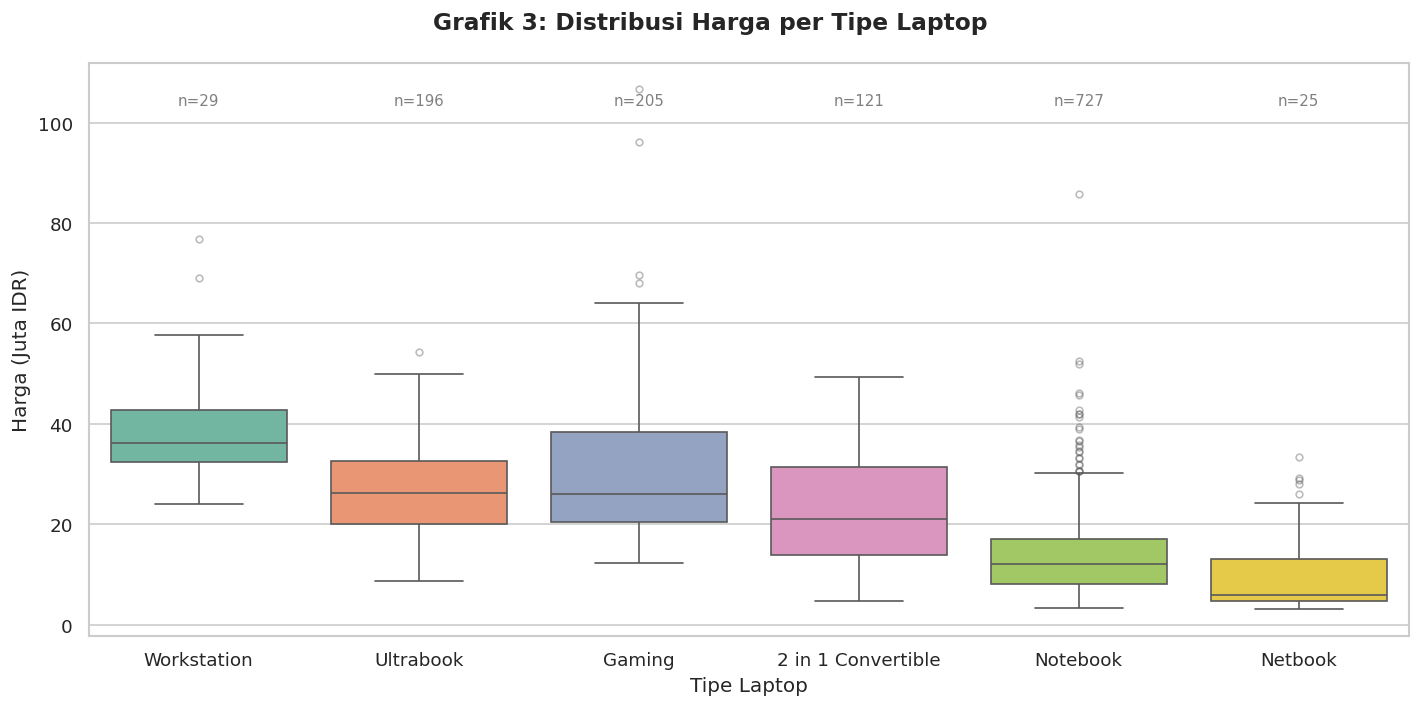

📊 Narasi: Workstation memiliki median harga tertinggi namun jumlah sedikit.
   Gaming laptop memiliki variasi harga paling lebar. Netbook konsisten
   sebagai pilihan paling terjangkau.


In [24]:
# ── Grafik 3: Boxplot Harga per Tipe Laptop ──────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Grafik 3: Distribusi Harga per Tipe Laptop', fontsize=14, fontweight='bold')

order_tipe = (df.groupby('TypeName')['Price_Juta']
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x='TypeName', y='Price_Juta', order=order_tipe,
            palette='Set2', ax=ax, flierprops={'marker':'o','markersize':4,'alpha':0.4})
ax.set_xlabel('Tipe Laptop')
ax.set_ylabel('Harga (Juta IDR)')
for i, tipe in enumerate(order_tipe):
    n = df[df['TypeName'] == tipe].shape[0]
    ax.text(i, df['Price_Juta'].max() * 0.97, f'n={n}',
            ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('grafik3_boxplot_tipe.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: Workstation memiliki median harga tertinggi namun jumlah sedikit.")
print("   Gaming laptop memiliki variasi harga paling lebar. Netbook konsisten")
print("   sebagai pilihan paling terjangkau.")

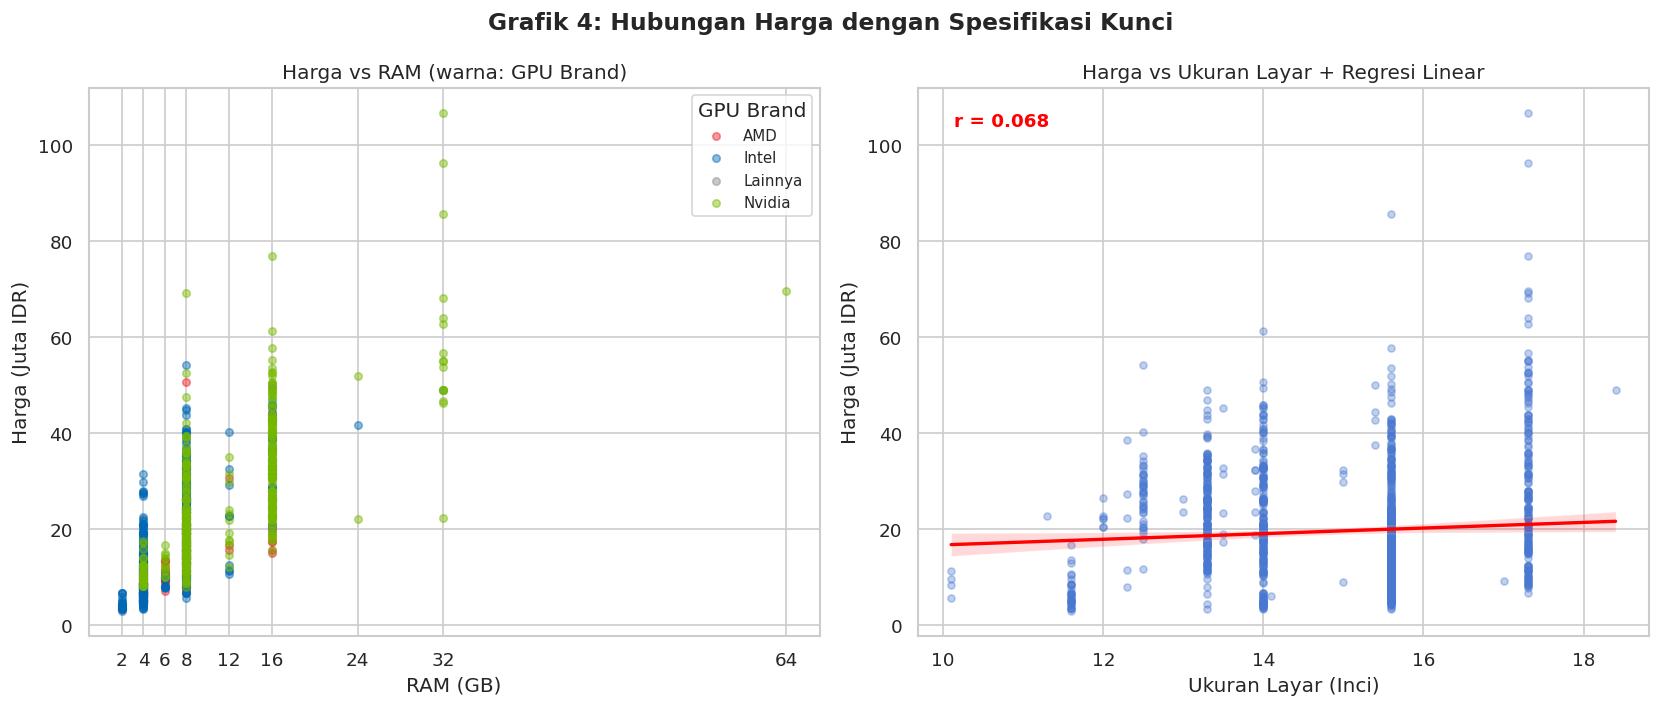

📊 Narasi: RAM 32GB+ hampir selalu memiliki GPU Nvidia, dan harganya jauh
   di atas rata-rata. Korelasi layar vs harga lemah (r ≈ 0.2), artinya
   ukuran layar besar tidak selalu berarti lebih mahal.


In [25]:
# ── Grafik 4: Scatter Harga vs RAM & Layar ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Grafik 4: Hubungan Harga dengan Spesifikasi Kunci', fontsize=14, fontweight='bold')

gpu_colors = {'Nvidia':'#76b900', 'Intel':'#0068b5', 'AMD':'#ed1c24', 'Lainnya':'#888888'}
for gpu, grp in df.groupby('GPU_Brand'):
    axes[0].scatter(grp['Ram_GB'], grp['Price_Juta'],
                    alpha=0.45, s=20, label=gpu, color=gpu_colors.get(gpu, 'gray'))
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Harga (Juta IDR)')
axes[0].set_title('Harga vs RAM (warna: GPU Brand)')
axes[0].legend(title='GPU Brand', fontsize=9)
axes[0].set_xticks(sorted(df['Ram_GB'].unique()))

sns.regplot(data=df, x='Inches', y='Price_Juta', ax=axes[1],
            scatter_kws={'alpha':0.35,'s':18}, line_kws={'color':'red','lw':2})
r = df['Inches'].corr(df['Price_Juta'])
axes[1].annotate(f'r = {r:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
                 fontsize=11, color='red', fontweight='bold')
axes[1].set_xlabel('Ukuran Layar (Inci)')
axes[1].set_ylabel('Harga (Juta IDR)')
axes[1].set_title('Harga vs Ukuran Layar + Regresi Linear')

plt.tight_layout()
plt.savefig('grafik4_scatter_spesifikasi.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: RAM 32GB+ hampir selalu memiliki GPU Nvidia, dan harganya jauh")
print("   di atas rata-rata. Korelasi layar vs harga lemah (r ≈ 0.2), artinya")
print("   ukuran layar besar tidak selalu berarti lebih mahal.")

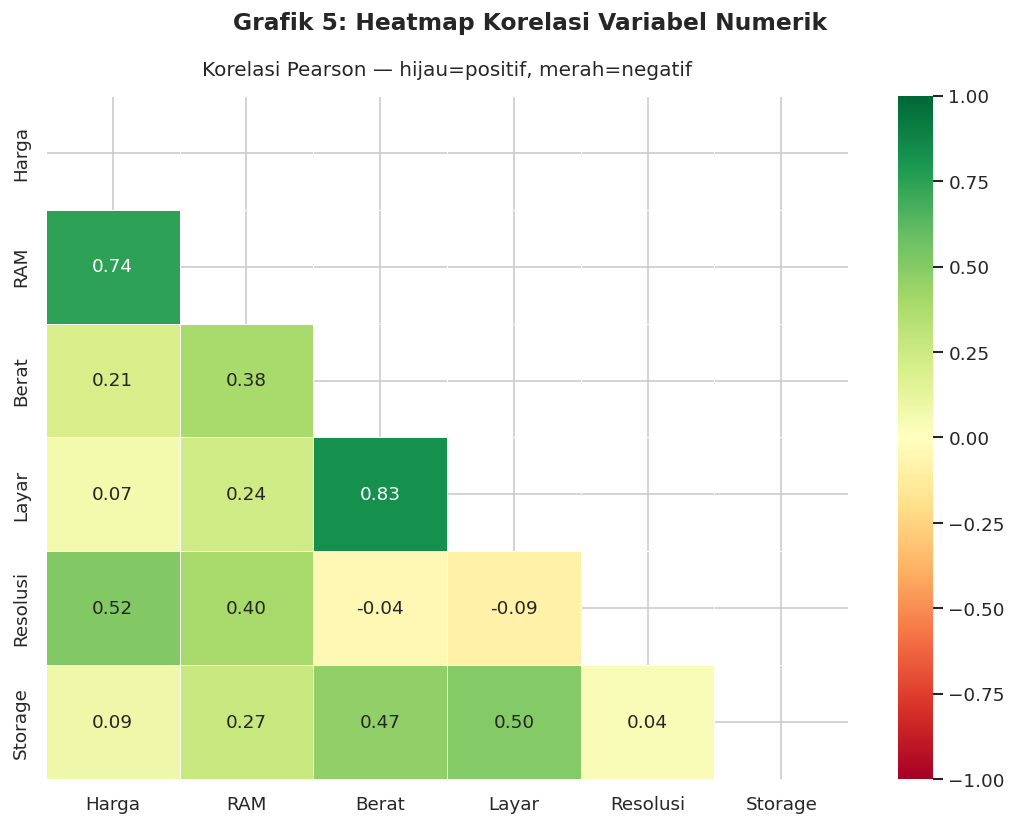

📊 Narasi: RAM memiliki korelasi paling kuat dengan harga (r ≈ 0.74).
   Berat berkorelasi positif dengan ukuran layar, logis karena laptop
   besar cenderung lebih berat. Storage tidak berkorelasi kuat dengan harga.


In [26]:
# ── Grafik 5: Heatmap Korelasi ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Grafik 5: Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold')

kolom_k = ['Price_IDR','Ram_GB','Weight_kg','Inches','Resolusi_pixel','Storage_GB']
label_k = ['Harga','RAM','Berat','Layar','Resolusi','Storage']
matriks = df[kolom_k].corr()
matriks.index = matriks.columns = label_k

mask = np.triu(np.ones_like(matriks, dtype=bool))
sns.heatmap(matriks, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size':11})
ax.set_title('Korelasi Pearson — hijau=positif, merah=negatif', pad=12)

plt.tight_layout()
plt.savefig('grafik5_heatmap_korelasi.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: RAM memiliki korelasi paling kuat dengan harga (r ≈ 0.74).")
print("   Berat berkorelasi positif dengan ukuran layar, logis karena laptop")
print("   besar cenderung lebih berat. Storage tidak berkorelasi kuat dengan harga.")

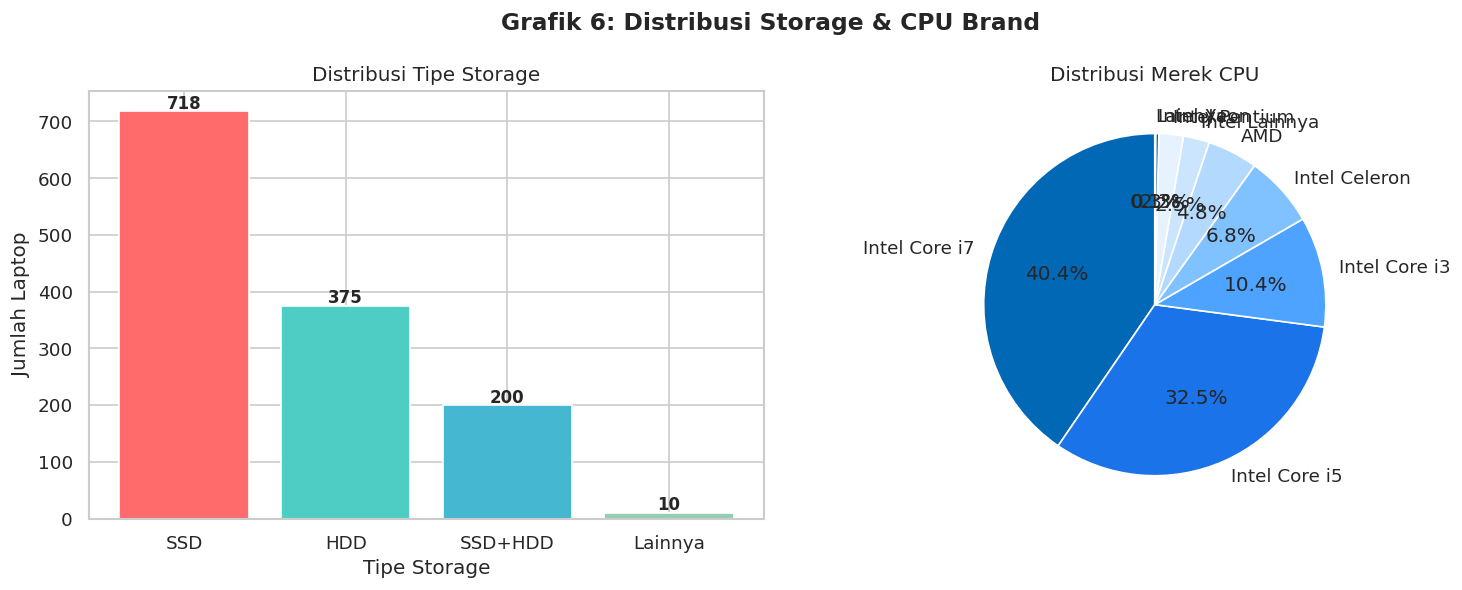

📊 Narasi: SSD sudah menjadi storage paling banyak digunakan, namun
   HDD masih signifikan terutama di segmen budget. Intel Core i5 dan i7
   mendominasi lebih dari 70% pasar laptop.


In [27]:
# ── Grafik 6: Storage Type & CPU Brand ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Grafik 6: Distribusi Storage & CPU Brand', fontsize=14, fontweight='bold')

storage_count = df['Storage_Type'].value_counts()
axes[0].bar(storage_count.index, storage_count.values,
            color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'], edgecolor='white')
for i, v in enumerate(storage_count.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Tipe Storage')
axes[0].set_ylabel('Jumlah Laptop')
axes[0].set_title('Distribusi Tipe Storage')

cpu_count  = df['CPU_Brand'].value_counts()
colors_cpu = ['#0068b5','#1a73e8','#4da3ff','#80c1ff','#b3d9ff','#cce5ff','#e6f2ff']
axes[1].pie(cpu_count.values, labels=cpu_count.index, autopct='%1.1f%%',
            colors=colors_cpu[:len(cpu_count)], startangle=90)
axes[1].set_title('Distribusi Merek CPU')

plt.tight_layout()
plt.savefig('grafik6_storage_cpu.png', bbox_inches='tight')
plt.show()
print("📊 Narasi: SSD sudah menjadi storage paling banyak digunakan, namun")
print("   HDD masih signifikan terutama di segmen budget. Intel Core i5 dan i7")
print("   mendominasi lebih dari 70% pasar laptop.")

---
## 📌 Tahap 6: Analisis & Identifikasi Masalah

In [28]:
# ── 6.1 Identifikasi Masalah ─────────────────────────────────
print("=" * 60)
print("  IDENTIFIKASI MASALAH DARI DATA LAPTOP")
print("=" * 60)

rata_apple  = df[df['Company'] == 'Apple']['Price_IDR'].mean()
rata_lenovo = df[df['Company'] == 'Lenovo']['Price_IDR'].mean()
selisih     = rata_apple - rata_lenovo
print(f"\n📌 MASALAH 1: Kesenjangan Harga Brand Premium vs Budget")
print(f"   Rata-rata Apple  : Rp {rata_apple:,.0f}")
print(f"   Rata-rata Lenovo : Rp {rata_lenovo:,.0f}")
print(f"   Selisih          : Rp {selisih:,.0f} ({selisih/rata_lenovo*100:.0f}% lebih mahal)")

q1_ram    = df['Ram_GB'].quantile(0.25)
q3_harga  = df['Price_IDR'].quantile(0.75)
overpriced = df[(df['Ram_GB'] <= q1_ram) & (df['Price_IDR'] >= q3_harga)]
print(f"\n📌 MASALAH 2: Laptop Berpotensi Overpriced")
print(f"   Ditemukan {len(overpriced)} laptop dengan RAM rendah (≤{q1_ram:.0f}GB) namun harga ≥ Q3")

hdd_budget   = df[(df['Storage_Type'] == 'HDD') & (df['Kategori_Harga'] == 'Budget (<7 Jt)')]
total_budget = df[df['Kategori_Harga'] == 'Budget (<7 Jt)']
print(f"\n📌 MASALAH 3: Laptop Budget Masih Didominasi HDD")
print(f"   {len(hdd_budget)} dari {len(total_budget)} laptop budget masih menggunakan HDD")
print(f"   Proporsi: {len(hdd_budget)/len(total_budget)*100:.1f}%")

gaming = df[df['TypeName'] == 'Gaming']
print(f"\n📌 MASALAH 4: Variasi Harga Gaming Sangat Lebar")
print(f"   Min: Rp {gaming['Price_IDR'].min():,}  |  Max: Rp {gaming['Price_IDR'].max():,}")
print(f"   Standar Deviasi: Rp {gaming['Price_IDR'].std():,.0f}")

  IDENTIFIKASI MASALAH DARI DATA LAPTOP

📌 MASALAH 1: Kesenjangan Harga Brand Premium vs Budget
   Rata-rata Apple  : Rp 27,373,475
   Rata-rata Lenovo : Rp 19,011,728
   Selisih          : Rp 8,361,747 (44% lebih mahal)

📌 MASALAH 2: Laptop Berpotensi Overpriced
   Ditemukan 7 laptop dengan RAM rendah (≤4GB) namun harga ≥ Q3

📌 MASALAH 3: Laptop Budget Masih Didominasi HDD
   75 dari 145 laptop budget masih menggunakan HDD
   Proporsi: 51.7%

📌 MASALAH 4: Variasi Harga Gaming Sangat Lebar
   Min: Rp 12,232,500  |  Max: Rp 106,732,500
   Standar Deviasi: Rp 14,248,053


In [29]:
# ── 6.2 Rekomendasi Solusi ────────────────────────────────────
rekomendasi = [
    ("Kesenjangan Harga Brand",
     "Gunakan SPK value-for-money (harga/spek) agar konsumen tidak terjebak brand image."),
    ("Laptop Overpriced",
     "Terapkan TOPSIS untuk ranking efisiensi harga; laptop RAM rendah harga tinggi akan turun peringkat."),
    ("HDD di Segmen Budget",
     "Produsen perlu beralih ke SSD entry-level; selisih biaya produksi kecil namun dampak performa besar."),
    ("Variasi Harga Gaming",
     "Gunakan SAW dengan bobot GPU & RAM lebih tinggi untuk bantu gamer pilih laptop sesuai anggaran.")
]
print("=" * 60)
print("  REKOMENDASI SOLUSI")
print("=" * 60)
for i, (masalah, solusi) in enumerate(rekomendasi, 1):
    print(f"\n✅ Solusi {i}: {masalah}")
    print(f"   {solusi}")

  REKOMENDASI SOLUSI

✅ Solusi 1: Kesenjangan Harga Brand
   Gunakan SPK value-for-money (harga/spek) agar konsumen tidak terjebak brand image.

✅ Solusi 2: Laptop Overpriced
   Terapkan TOPSIS untuk ranking efisiensi harga; laptop RAM rendah harga tinggi akan turun peringkat.

✅ Solusi 3: HDD di Segmen Budget
   Produsen perlu beralih ke SSD entry-level; selisih biaya produksi kecil namun dampak performa besar.

✅ Solusi 4: Variasi Harga Gaming
   Gunakan SAW dengan bobot GPU & RAM lebih tinggi untuk bantu gamer pilih laptop sesuai anggaran.


---
## 🏆 Tahap 7: Sistem Pendukung Keputusan (SPK)
**Tujuan:** Membantu konsumen memilih laptop terbaik di segmen mid-range.  
**Metode:** SAW & TOPSIS — diimplementasi **manual** dengan NumPy (tanpa library SPK eksternal).

| Kriteria | Tipe | Bobot | Alasan |
|---|---|---|---|
| RAM (GB) | Benefit ↑ | 25% | Makin besar makin responsif |
| Storage (GB) | Benefit ↑ | 15% | Kapasitas simpan data |
| Resolusi layar | Benefit ↑ | 20% | Kualitas tampilan |
| Harga (IDR) | Cost ↓ | 30% | Makin murah makin baik |
| Berat (kg) | Cost ↓ | 10% | Portabilitas |

In [30]:
# ── 7.1 Persiapan Data Kandidat SPK ─────────────────────────
df_spk = (
    df[
        (df['Price_IDR'] >= 7_000_000) &
        (df['Price_IDR'] <= 21_000_000) &
        df['Storage_GB'].notna() &
        df['Resolusi_pixel'].notna()
    ]
    .copy()
    .drop_duplicates(subset=['Company', 'Product'])
    .nlargest(20, 'Resolusi_pixel')
    .reset_index(drop=True)
)

KOLOM_KRITERIA = ['Ram_GB', 'Storage_GB', 'Resolusi_pixel', 'Price_IDR', 'Weight_kg']
TIPE_KRITERIA  = ['benefit', 'benefit', 'benefit', 'cost', 'cost']
BOBOT          = np.array([0.25, 0.15, 0.20, 0.30, 0.10])

assert abs(BOBOT.sum() - 1.0) < 1e-9, "Total bobot harus = 1.0"

matriks = df_spk[KOLOM_KRITERIA].values.astype(float)

print(f"✅ Kandidat laptop : {len(df_spk)} unit")
print(f"✅ Total bobot     : {BOBOT.sum():.2f}")
print()
df_spk[['Company','Product','TypeName'] + KOLOM_KRITERIA].head(10)

✅ Kandidat laptop : 20 unit
✅ Total bobot     : 1.00



,Company,Product,TypeName,Ram_GB,Storage_GB,Resolusi_pixel,Price_IDR,Weight_kg
0,Razer,Blade Stealth,Ultrabook,8,256,8294400,18007500,1.25
1,HP,Envy 13-AB020nr,Ultrabook,8,256,5760000,20037500,1.34
2,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,8,256,5760000,20982500,1.30
3,Asus,Zenbook UX330UA-AH5Q,Ultrabook,8,256,5760000,19757500,1.20
4,HP,Envy 13-AB077cl,Ultrabook,8,256,5760000,20107500,1.39
5,Asus,ZenBook UX310UA-FB485T,Notebook,8,256,5760000,20125000,1.40
6,HP,Chromebook 13,Notebook,4,32,5760000,10762500,1.29
7,Chuwi,LapBook 12.3,Notebook,6,64,4990464,7857500,1.40
8,Samsung,Chromebook Plus,2 in 1 Convertible,4,32,3840000,11532500,1.15
9,Microsoft,Surface Laptop,Ultrabook,4,128,3393024,19057500,1.25


In [31]:
# ── 7.2 Metode SAW (Simple Additive Weighting) ───────────────
"""
Algoritma SAW:
  1. Normalisasi: benefit = xi/max(x), cost = min(x)/xi
  2. Nilai terbobot = bobot × nilai_ternormalisasi
  3. Skor SAW = jumlah nilai terbobot per alternatif
"""

def normalisasi_saw(matriks, tipe_kriteria):
    hasil = np.zeros_like(matriks, dtype=float)
    for j, tipe in enumerate(tipe_kriteria):
        kolom = matriks[:, j]
        hasil[:, j] = kolom / kolom.max() if tipe == 'benefit' else kolom.min() / kolom
    return hasil

norm_saw    = normalisasi_saw(matriks, TIPE_KRITERIA)
skor_saw    = (norm_saw * BOBOT).sum(axis=1)

df_spk['Skor_SAW']    = skor_saw
df_spk['Ranking_SAW'] = df_spk['Skor_SAW'].rank(ascending=False).astype(int)

print("=== HASIL METODE SAW — TOP 10 ===")
top10 = (df_spk[['Company','Product','Ram_GB','Price_IDR','Skor_SAW','Ranking_SAW']]
         .sort_values('Ranking_SAW').head(10).copy())
top10['Price_IDR'] = top10['Price_IDR'].apply(lambda x: f"Rp {x:,}")
top10['Skor_SAW']  = top10['Skor_SAW'].round(4)
print(top10.to_string(index=False))

=== HASIL METODE SAW — TOP 10 ===
Company                Product  Ram_GB     Price_IDR  Skor_SAW  Ranking_SAW
 Lenovo      IdeaPad 320-15IKB       8  Rp 8,732,500      0.75            1
  Razer          Blade Stealth       8 Rp 18,007,500      0.67            2
  Chuwi           LapBook 12.3       6  Rp 7,857,500      0.67            3
 Lenovo     Legion Y520-15IKBN       8 Rp 17,482,500      0.61            4
     HP                 250 G6       8 Rp 10,062,500      0.61            5
   Asus   Zenbook UX330UA-AH5Q       8 Rp 19,757,500      0.60            6
  Apple            MacBook 12"       8 Rp 20,387,500      0.60            7
     HP        Envy 13-AB020nr       8 Rp 20,037,500      0.60            8
     HP        Envy 13-AB077cl       8 Rp 20,107,500      0.59            9
   Asus ZenBook UX310UA-FB485T       8 Rp 20,125,000      0.59           10


In [32]:
# ── 7.3 Metode TOPSIS ────────────────────────────────────────
"""
Algoritma TOPSIS:
  1. Normalisasi vektor: xi / sqrt(sum(xi^2))
  2. Normalisasi terbobot: bobot × nilai_ternormalisasi
  3. Solusi ideal positif (A+): max benefit, min cost
  4. Solusi ideal negatif (A-): min benefit, max cost
  5. Jarak Euclidean ke A+ dan A-
  6. Skor preferensi = D- / (D+ + D-)
"""

def hitung_topsis(matriks, bobot, tipe_kriteria):
    # Step 1 & 2: Normalisasi vektor terbobot
    norm_vektor = matriks / np.sqrt((matriks ** 2).sum(axis=0))
    norm_tbt    = norm_vektor * bobot

    # Step 3 & 4: Solusi ideal
    ideal_pos = np.array([
        norm_tbt[:, j].max() if t == 'benefit' else norm_tbt[:, j].min()
        for j, t in enumerate(tipe_kriteria)
    ])
    ideal_neg = np.array([
        norm_tbt[:, j].min() if t == 'benefit' else norm_tbt[:, j].max()
        for j, t in enumerate(tipe_kriteria)
    ])

    # Step 5: Jarak Euclidean
    d_pos = np.sqrt(((norm_tbt - ideal_pos) ** 2).sum(axis=1))
    d_neg = np.sqrt(((norm_tbt - ideal_neg) ** 2).sum(axis=1))

    # Step 6: Skor preferensi
    skor = d_neg / (d_pos + d_neg)
    return skor

skor_topsis = hitung_topsis(matriks, BOBOT, TIPE_KRITERIA)

df_spk['Skor_TOPSIS']    = skor_topsis
df_spk['Ranking_TOPSIS'] = df_spk['Skor_TOPSIS'].rank(ascending=False).astype(int)

print("=== HASIL METODE TOPSIS — TOP 10 ===")
top10t = (df_spk[['Company','Product','Ram_GB','Price_IDR','Skor_TOPSIS','Ranking_TOPSIS']]
          .sort_values('Ranking_TOPSIS').head(10).copy())
top10t['Price_IDR']    = top10t['Price_IDR'].apply(lambda x: f"Rp {x:,}")
top10t['Skor_TOPSIS']  = top10t['Skor_TOPSIS'].round(4)
print(top10t.to_string(index=False))

=== HASIL METODE TOPSIS — TOP 10 ===
Company              Product  Ram_GB     Price_IDR  Skor_TOPSIS  Ranking_TOPSIS
 Lenovo    IdeaPad 320-15IKB       8  Rp 8,732,500         0.60               1
 Lenovo   Legion Y520-15IKBN       8 Rp 17,482,500         0.53               2
  Razer        Blade Stealth       8 Rp 18,007,500         0.50               3
  Chuwi         LapBook 12.3       6  Rp 7,857,500         0.43               4
  Apple          MacBook 12"       8 Rp 20,387,500         0.40               5
   Asus Zenbook UX330UA-AH5Q       8 Rp 19,757,500         0.39               6
     HP               250 G6       8 Rp 10,062,500         0.39               7
     HP        Chromebook 13       4 Rp 10,762,500         0.39               8
     HP      Envy 13-AB020nr       8 Rp 20,037,500         0.39               9
     HP      Envy 13-AB077cl       8 Rp 20,107,500         0.39              10


In [33]:
# ── 7.4 Perbandingan SAW vs TOPSIS ───────────────────────────
print("=== PERBANDINGAN RANKING SAW vs TOPSIS ===")
perbandingan = (
    df_spk[['Company','Product','Ranking_SAW','Skor_SAW','Ranking_TOPSIS','Skor_TOPSIS']]
    .sort_values('Ranking_SAW').head(10).copy()
)
perbandingan['Skor_SAW']     = perbandingan['Skor_SAW'].round(4)
perbandingan['Skor_TOPSIS']  = perbandingan['Skor_TOPSIS'].round(4)
perbandingan['Delta_Rank']   = (perbandingan['Ranking_SAW'] - perbandingan['Ranking_TOPSIS']).abs()
print(perbandingan.to_string(index=False))

# Korelasi Spearman
from scipy.stats import spearmanr
rho, p = spearmanr(df_spk['Ranking_SAW'], df_spk['Ranking_TOPSIS'])
print(f"\nKorelasi Spearman: ρ = {rho:.4f}  (p = {p:.4f})")
print("→ " + ("Kedua metode sangat konsisten ✅" if rho > 0.8 else "Ada perbedaan ranking signifikan ⚠️"))

=== PERBANDINGAN RANKING SAW vs TOPSIS ===
Company                Product  Ranking_SAW  Skor_SAW  Ranking_TOPSIS  Skor_TOPSIS  Delta_Rank
 Lenovo      IdeaPad 320-15IKB            1      0.75               1         0.60           0
  Razer          Blade Stealth            2      0.67               3         0.50           1
  Chuwi           LapBook 12.3            3      0.67               4         0.43           1
 Lenovo     Legion Y520-15IKBN            4      0.61               2         0.53           2
     HP                 250 G6            5      0.61               7         0.39           2
   Asus   Zenbook UX330UA-AH5Q            6      0.60               6         0.39           0
  Apple            MacBook 12"            7      0.60               5         0.40           2
     HP        Envy 13-AB020nr            8      0.60               9         0.39           1
     HP        Envy 13-AB077cl            9      0.59              10         0.39           1
   Asus

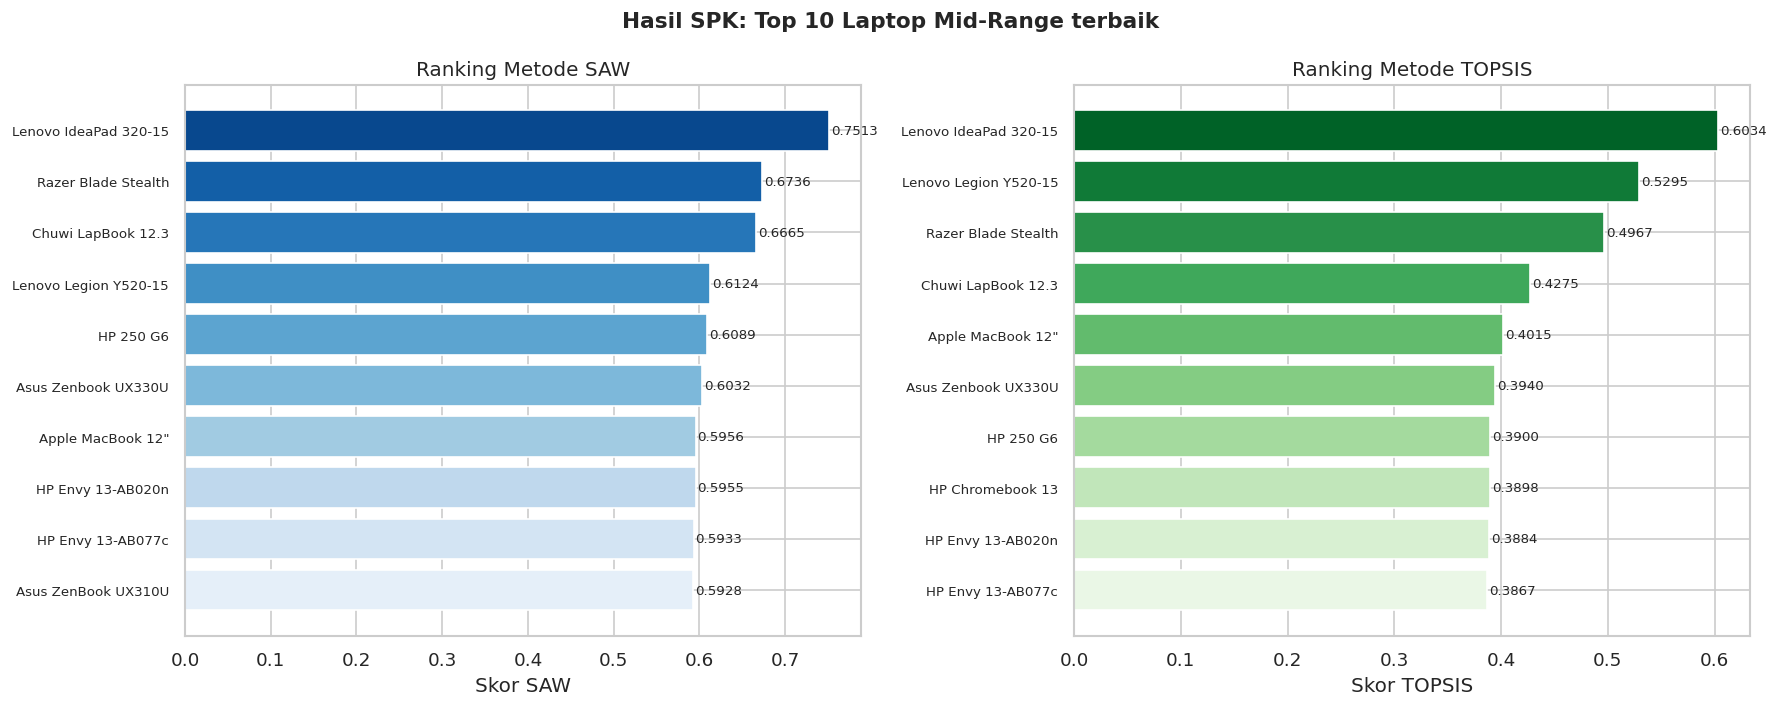

✅ Grafik SPK tersimpan.


In [34]:
# ── 7.5 Visualisasi Hasil SPK ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Hasil SPK: Top 10 Laptop Mid-Range terbaik', fontsize=13, fontweight='bold')

for ax, metode, kolom_skor, kolom_rank, warna in [
    (axes[0], 'SAW',    'Skor_SAW',    'Ranking_SAW',    'Blues_r'),
    (axes[1], 'TOPSIS', 'Skor_TOPSIS', 'Ranking_TOPSIS', 'Greens_r'),
]:
    top10 = df_spk.nsmallest(10, kolom_rank).sort_values(kolom_rank)
    labels = [f"{r['Company']} {r['Product'][:14]}" for _, r in top10.iterrows()]
    bars   = ax.barh(range(10), top10[kolom_skor],
                     color=sns.color_palette(warna, 10))
    ax.set_yticks(range(10))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(f'Skor {metode}')
    ax.set_title(f'Ranking Metode {metode}')
    ax.invert_yaxis()
    for bar, val in zip(bars, top10[kolom_skor]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('grafik7_hasil_spk.png', bbox_inches='tight')
plt.show()
print("✅ Grafik SPK tersimpan.")

---
## 📝 Tahap 8: Kesimpulan & Rekomendasi

### Ringkasan Temuan Utama

| No | Temuan | Detail |
|---|---|---|
| 1 | Brand terbanyak | Lenovo mendominasi pasar |
| 2 | Harga rata-rata | ~Rp 19,6 Juta |
| 3 | RAM terpopuler | 8GB |
| 4 | Storage dominan | SSD sudah menggeser HDD |
| 5 | CPU dominan | Intel Core i5 (>30%) |
| 6 | Korelasi terkuat | RAM → Harga (r ≈ 0.74) |

### Kesimpulan SPK
- **SAW** cocok untuk pengguna yang ingin perhitungan transparan dan mudah dipahami
- **TOPSIS** lebih presisi karena mempertimbangkan jarak ke solusi ideal positif maupun negatif
- Korelasi Spearman tinggi antara dua metode → kriteria yang dipilih konsisten dan valid

### Rekomendasi Konsumen
1. **Budget (<7 Jt)** → Prioritaskan SSD meski kecil; lebih responsif dari HDD besar
2. **Mid-Range (7–14 Jt)** → Gunakan hasil SPK; sweet spot: RAM 16GB + SSD 512GB
3. **High-End (>14 Jt)** → Pastikan ada GPU diskret (Nvidia/AMD) untuk kerja kreatif/gaming
4. **Hindari** laptop RAM 4GB di harga >7 Juta — berpotensi overpriced

In [35]:
# ── Ringkasan Akhir ───────────────────────────────────────────
best_saw    = df_spk.loc[df_spk['Ranking_SAW'] == 1].iloc[0]
best_topsis = df_spk.loc[df_spk['Ranking_TOPSIS'] == 1].iloc[0]

print("=" * 60)
print("  RINGKASAN PROYEK AKHIR")
print("=" * 60)
print(f"  Dataset         : Laptop Price Dataset (Kaggle)")
print(f"  Total data      : {len(df):,} laptop | {df.shape[1]} kolom")
print(f"  Kandidat SPK    : {len(df_spk)} laptop mid-range")
print()
print("  STATISTIK HARGA:")
print(f"    Termurah  : Rp {df['Price_IDR'].min():,}")
print(f"    Termahal  : Rp {df['Price_IDR'].max():,}")
print(f"    Median    : Rp {df['Price_IDR'].median():,.0f}")
print()
print("  🥇 REKOMENDASI TERBAIK (SAW):")
print(f"    {best_saw['Company']} {best_saw['Product']}")
print(f"    RAM {best_saw['Ram_GB']}GB | Storage {best_saw['Storage_GB']:.0f}GB | Rp {best_saw['Price_IDR']:,}")
print()
print("  🥇 REKOMENDASI TERBAIK (TOPSIS):")
print(f"    {best_topsis['Company']} {best_topsis['Product']}")
print(f"    RAM {best_topsis['Ram_GB']}GB | Storage {best_topsis['Storage_GB']:.0f}GB | Rp {best_topsis['Price_IDR']:,}")
print()
print("=" * 60)
print("  ✅ Proyek selesai — semua tahap terpenuhi!")
print("=" * 60)

  RINGKASAN PROYEK AKHIR
  Dataset         : Laptop Price Dataset (Kaggle)
  Total data      : 1,303 laptop | 22 kolom
  Kandidat SPK    : 20 laptop mid-range

  STATISTIK HARGA:
    Termurah  : Rp 3,045,000
    Termahal  : Rp 106,732,500
    Median    : Rp 17,097,500

  🥇 REKOMENDASI TERBAIK (SAW):
    Lenovo IdeaPad 320-15IKB
    RAM 8GB | Storage 1024GB | Rp 8,732,500

  🥇 REKOMENDASI TERBAIK (TOPSIS):
    Lenovo IdeaPad 320-15IKB
    RAM 8GB | Storage 1024GB | Rp 8,732,500

  ✅ Proyek selesai — semua tahap terpenuhi!
